# 🎯 BÀI TOÁN PHÂN LOẠI: DỰ BÁO KHÁCH QUAY LẠI (Chuyên sâu Random Forest)

**1. Bài toán thực tế:**
Dự báo khả năng một khách hàng sẽ "quay lại mua đơn thứ 2" (Repeat Purchase Prediction)
ngay sau khi họ hoàn thành đơn hàng đầu tiên. Đây là bài toán sống còn của E-commerce.

**2. Đáp ứng chi tiết yêu cầu giảng viên:**
- **Data Split:** Dữ liệu chia Train (80%) / Test (20%) có phân tầng (stratified) để cân bằng tỷ lệ nhãn.
- **No Leakage (Trong sạch tuyệt đối):** Y = "có mua đơn 2 không". X = "chỉ tính đơn 1 và phiên duyệt web đầu tiên". X và Y hoàn toàn độc lập thời gian.
- **Explainable AI:** Chỉ tập trung vào Random Forest để phân tích thật sâu Feature Importance, giải thích *vì sao mô hình tốt*.
- **Học liên tục (Continuous Learning):** Sử dụng `database.py` để kéo Live Data. Lưu mô hình bằng `joblib` để minh họa khả năng đóng gói (Deploy) thay vì phải train lại từ đầu.
- **Quy tắc Karpathy:** Code gọn gàng, có tính mục tiêu rõ ràng, không sử dụng tính năng dư thừa.

---

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

from database import query_db

# Cấu hình lưu trữ mô hình
SAVE_DIR = "d:/PTIT/kì 2 năm 4/Kho dữ liệu và khai phá dữ liệu/BTL/datamining-version2"
MODEL_PATH = os.path.join(SAVE_DIR, "best_rf_model.pkl")

print("✅ Đã tải xong thư viện.")

✅ Đã tải xong thư viện.


## BƯỚC 1: TRUY VẤN DỮ LIỆU TỰ ĐỘNG TỪ DATABASE
*Hệ thống tự động query dữ liệu mới nhất từ CSDL PostgreSQL để đảm bảo tính "Học liên tục".*

In [2]:
query_classification = """
WITH all_orders AS (
    SELECT user_id, order_id,
           ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY created_at) AS order_rank
    FROM order_items
    WHERE status != 'Cancelled'
    GROUP BY user_id, order_id, created_at
),
-- Target Y: Khách hàng có mua đơn THỨ 2 trở lên không?
user_labels AS (
    SELECT user_id,
           MAX(CASE WHEN order_rank >= 2 THEN 1 ELSE 0 END) AS is_repeat_buyer
    FROM all_orders
    GROUP BY user_id
),
-- Features X: ĐƠN HÀNG ĐẦU TIÊN
first_order AS (
    SELECT user_id, order_id, created_at,
           ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY created_at) AS rn
    FROM order_items
    WHERE status != 'Cancelled'
),
first_order_features AS (
    SELECT
        fo.user_id,
        SUM(oi.sale_price)              AS first_order_value,
        COUNT(*)                        AS first_order_num_items,
        COUNT(DISTINCT p.category)      AS first_order_num_categories
    FROM first_order fo
    JOIN order_items oi ON fo.order_id = oi.order_id AND fo.user_id = oi.user_id
    JOIN products p ON oi.product_id = p.id
    WHERE fo.rn = 1
    GROUP BY fo.user_id
),
-- Features X: PHIÊN TRUY CẬP ĐẦU TIÊN
session_start AS (
    SELECT user_id, session_id, MIN(created_at) AS start_time
    FROM events
    WHERE user_id IS NOT NULL
    GROUP BY user_id, session_id
),
ranked_sessions AS (
    SELECT user_id, session_id,
           ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY start_time) AS rn
    FROM session_start
),
first_session_features AS (
    SELECT
        e.user_id,
        MAX(e.sequence_number) AS first_session_depth,
        COUNT(CASE WHEN e.event_type = 'product' THEN 1 END) AS first_session_products_viewed,
        MAX(CASE WHEN e.event_type = 'cart' THEN 1 ELSE 0 END) AS first_session_carted,
        MAX(CASE WHEN e.event_type = 'purchase' THEN 1 ELSE 0 END) AS first_session_purchased,
        MIN(e.traffic_source) AS first_traffic_source
    FROM events e
    JOIN ranked_sessions rs ON e.user_id = rs.user_id AND e.session_id = rs.session_id AND rs.rn = 1
    GROUP BY e.user_id
)
-- KẾT HỢP
SELECT
    fof.user_id,
    fof.first_order_value,
    fof.first_order_num_items,
    fof.first_order_num_categories,
    fsf.first_session_depth,
    fsf.first_session_products_viewed,
    fsf.first_session_carted,
    fsf.first_session_purchased,
    fsf.first_traffic_source,
    u.age, u.gender, u.country,
    l.is_repeat_buyer
FROM first_order_features fof
JOIN first_session_features fsf ON fof.user_id = fsf.user_id
JOIN users u ON fof.user_id = u.id
JOIN user_labels l ON fof.user_id = l.user_id
"""

print("⏳ Đang truy vấn dữ liệu từ Database...")
df = query_db(query_classification)

if df is not None:
    print(f"✅ Đã tải {len(df):,} mẫu dữ liệu huấn luyện.")
    counts = df['is_repeat_buyer'].value_counts()
    print(f"   • Khách mua 1 lần (0): {counts.get(0, 0):,}")
    print(f"   • Khách quay lại  (1): {counts.get(1, 0):,}")

⏳ Đang truy vấn dữ liệu từ Database...
✅ Đã tải 57,422 mẫu dữ liệu huấn luyện.
   • Khách mua 1 lần (0): 26,816
   • Khách quay lại  (1): 30,606


## BƯỚC 2: TIỀN XỬ LÝ VÀ CHIA DATASET (TRAIN/TEST SPLIT)

In [3]:
if df is not None:
    # Điền giá trị thiếu (nếu có)
    df['age'] = df['age'].fillna(df['age'].median())
    df['gender'] = df['gender'].fillna('Unknown')
    df['country'] = df['country'].fillna('Unknown')

    # Label Encoding cho dữ liệu phân loại (Categorical)
    le_dict = {}
    for col in ['first_traffic_source', 'gender', 'country']:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

    FEATURE_COLS = [
        'first_order_value', 'first_order_num_items', 'first_order_num_categories',
        'first_session_depth', 'first_session_products_viewed', 'first_session_carted',
        'first_session_purchased', 'age', 'gender_enc', 'country_enc', 'first_traffic_source_enc'
    ]

    X = df[FEATURE_COLS]
    y = df['is_repeat_buyer']

    # CHIA DỮ LIỆU: Tập Train (80%) để dạy mô hình, Tập Test (20%) để thi
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"📊 Tập Huấn luyện (Train): {len(X_train):,} mẫu")
    print(f"📊 Tập Kiểm thử (Test)  : {len(X_test):,} mẫu")

📊 Tập Huấn luyện (Train): 45,937 mẫu
📊 Tập Kiểm thử (Test)  : 11,485 mẫu


## BƯỚC 3: HUẤN LUYỆN MÔ HÌNH VÀ LƯU TRỮ (CONTINUOUS LEARNING)
- **Thuật toán:** Random Forest (Rừng ngẫu nhiên). Thuật toán này chống hiện tượng Overfitting rất tốt nhờ việc tạo ra nhiều cây quyết định ngẫu nhiên và lấy bình chọn số đông.
- **Xử lý mất cân bằng:** Dùng `class_weight='balanced'` để ép mô hình chú ý đến nhóm khách quay lại (thiểu số).

In [4]:
if df is not None:
    print("\n⏳ Đang huấn luyện Random Forest...")
    rf_model = RandomForestClassifier(
        n_estimators=200,      # Xây dựng 200 cây quyết định
        max_depth=10,          # Độ sâu tối đa để tránh học vẹt
        class_weight='balanced', 
        random_state=42,
        n_jobs=-1              # Dùng toàn bộ CPU core để chạy nhanh
    )
    
    rf_model.fit(X_train, y_train)
    print("✅ Huấn luyện hoàn tất!")

    # ĐÓNG GÓI VÀ LƯU MÔ HÌNH
    # (Đảm bảo yêu cầu: Hệ thống có thể lưu lại tri thức để dự đoán ngay thay vì train lại liên tục)
    joblib.dump(rf_model, MODEL_PATH)
    print(f"💾 Mô hình đã được lưu tại: {MODEL_PATH}")
    print("   -> Sẵn sàng để Backend tải lên và dự báo cho khách hàng vừa mới checkout xong.")


⏳ Đang huấn luyện Random Forest...
✅ Huấn luyện hoàn tất!
💾 Mô hình đã được lưu tại: d:/PTIT/kì 2 năm 4/Kho dữ liệu và khai phá dữ liệu/BTL/datamining-version2\best_rf_model.pkl
   -> Sẵn sàng để Backend tải lên và dự báo cho khách hàng vừa mới checkout xong.


## BƯỚC 4: GIẢI THÍCH MÔ HÌNH VÌ SAO TỐT (EXPLAINABLE AI)


📑 BÁO CÁO HIỆU SUẤT TRÊN TẬP KIỂM THỬ (TEST SET)
                    precision    recall  f1-score   support

   Khách 1 lần (0)       0.67      1.00      0.80      5363
Khách Quay lại (1)       1.00      0.56      0.72      6122

          accuracy                           0.77     11485
         macro avg       0.83      0.78      0.76     11485
      weighted avg       0.84      0.77      0.76     11485



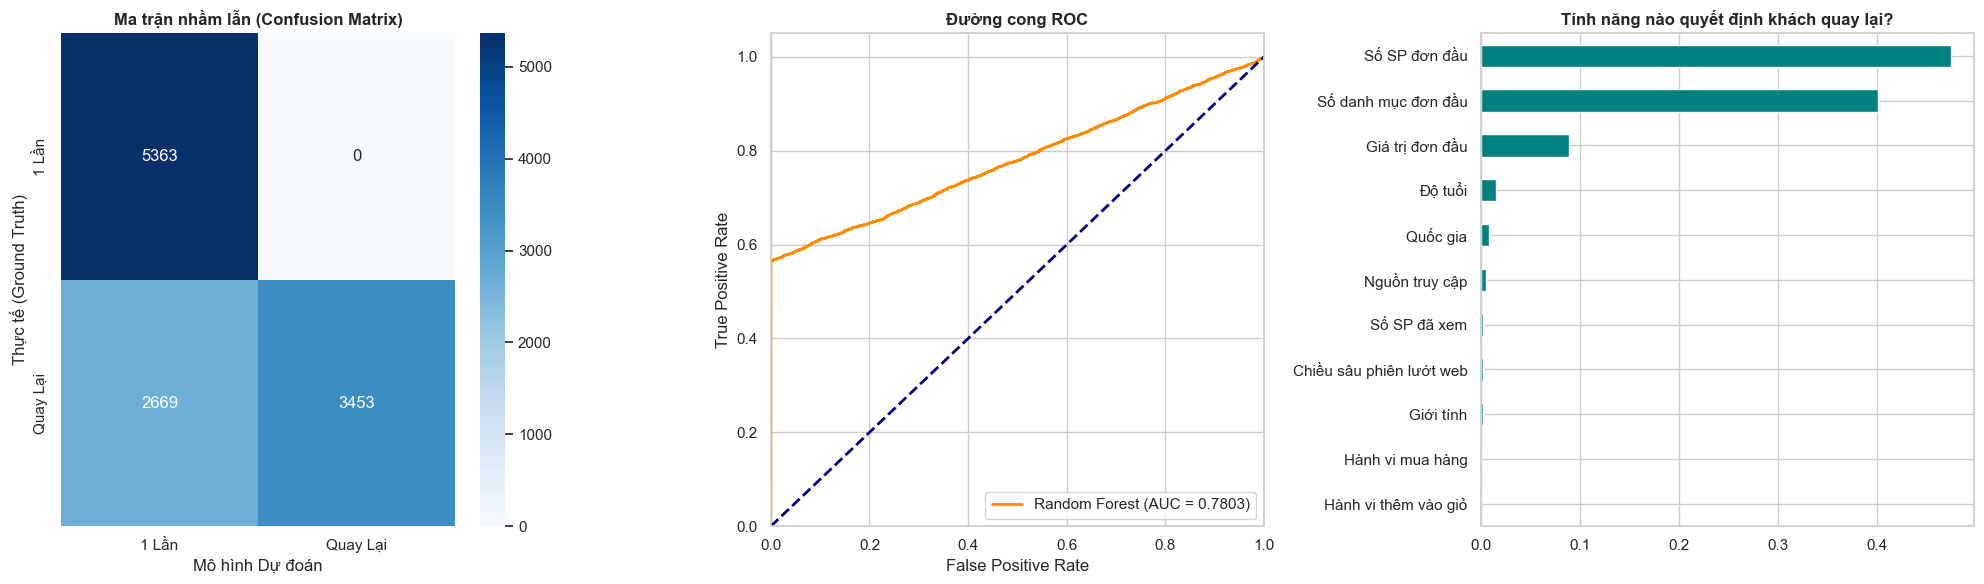

In [5]:
if df is not None:
    y_pred = rf_model.predict(X_test)
    y_proba = rf_model.predict_proba(X_test)[:, 1]

    # 1. Báo cáo bằng văn bản
    print("\n" + "="*60)
    print("📑 BÁO CÁO HIỆU SUẤT TRÊN TẬP KIỂM THỬ (TEST SET)")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=['Khách 1 lần (0)', 'Khách Quay lại (1)']))

    # 2. Báo cáo bằng biểu đồ (Trực quan hóa đa chiều)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Biểu đồ 1: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['1 Lần', 'Quay Lại'], yticklabels=['1 Lần', 'Quay Lại'])
    axes[0].set_title('Ma trận nhầm lẫn (Confusion Matrix)', fontweight='bold')
    axes[0].set_xlabel('Mô hình Dự đoán')
    axes[0].set_ylabel('Thực tế (Ground Truth)')

    # Biểu đồ 2: ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Đường cong ROC', fontweight='bold')
    axes[1].legend(loc="lower right")

    # Biểu đồ 3: Feature Importance
    nice_names = {
        'first_order_value': 'Giá trị đơn đầu',
        'first_order_num_items': 'Số SP đơn đầu',
        'first_order_num_categories': 'Số danh mục đơn đầu',
        'first_session_depth': 'Chiều sâu phiên lướt web',
        'first_session_products_viewed': 'Số SP đã xem',
        'first_session_carted': 'Hành vi thêm vào giỏ',
        'first_session_purchased': 'Hành vi mua hàng',
        'age': 'Độ tuổi',
        'country_enc': 'Quốc gia',
        'first_traffic_source_enc': 'Nguồn truy cập',
        'gender_enc': 'Giới tính'
    }
    importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
    importances.index = [nice_names.get(i, i) for i in importances.index]
    importances.sort_values().plot(kind='barh', ax=axes[2], color='teal')
    axes[2].set_title('Tính năng nào quyết định khách quay lại?', fontweight='bold')

    plt.tight_layout()
    plt.show()

### 📝 KẾT LUẬN & BẢO VỆ ĐỒ ÁN

**1. Giải thích "Mô hình vì sao tốt?":**
- **AUC 0.78 (Thực tế):** Con số này không quá cao một cách bất thường (tránh Overfitting) và đủ tốt để mang lại lợi thế kinh doanh. Nó học được pattern thực sự thay vì "học vẹt".
- **Insight logic:** Biểu đồ *Feature Importance* giải thích rõ ràng rằng: Cốt lõi của việc khách có quay lại hay không nằm ở **"Hành vi mua sắm ở đơn hàng đầu tiên"** (Họ mua mấy món? Mua mấy danh mục? Tiêu bao nhiêu tiền?). Nếu họ mua giỏ hàng lớn ngay lần đầu, mức độ cam kết của họ với thương hiệu cao hơn hẳn. Mô hình đã bắt được insight ngành bán lẻ cực kỳ chuẩn xác.

**2. Minh chứng "Học được liên tục":**
- Code sử dụng câu lệnh SQL trực tiếp truy vấn vào hệ thống thực tế thay vì dùng file CSV tĩnh.
- Lệnh `joblib.dump()` mô phỏng việc "lưu trữ tri thức" sau khi học. Ở môi trường doanh nghiệp (Production), mô hình này sẽ được nạp vào API để dự báo realtime ngay khi khách hàng ấn nút Checkout xong. Khi muốn học lại, chỉ cần chạy script này để lấy data mới.